# Markov Models

In this lab we will use Markov models to study human languages.

## Data Preparation

Before we can actually think about mathematical modeling, we need to gather some sample data to work on. For this lab, we will be retrieving text from the website of [Project Gutenberg](https://www.gutenberg.org/).

Go to that project website and find the page for "The Hound of the Baskervilles" novel. In particular, load the simple text form of the book.

Now define a Python variable `novel` and assign to it the first few paragraphs of Chapter 1.

all characters that are not letters or spaces<div class="alert alert-info">
In Python there is a specific syntax to define multi-line strings. If you use such syntax, you can simply copy and paste the novel text from the Project Gutenberg website.
</div>

In [2]:
novel = """
“   How did he do it? That’s what I’d like to know.”

“So would I. It sure was a queer trick all right—and it looked so easy, too.”

“Well, I’ve tried to guess, but I can’t. The more I think of it the more I believe that the professor really is a magician, in a certain way.”

“Pooh! It couldn’t be anything like that! It was just a trick, like all the others he did. But I’d like to know how to do it.”

Four boys sat under the shade of a big willow tree in a grassy meadow on the bank of a stream. They were earnestly discussing something, the import of which may be gathered from their talk.

“I tried to do the trick after I got home last night,” confessed Harry Martin.

2“You didn’t do it, did you?” asked Charlie Ford, rumpling up his red hair. Charlie was not at all ashamed of his red hair. His sister Mazie called it “auburn,” but Charlie himself stuck to plain “red.”

“Do it? I should say not!” cried Harry. “I didn’t come within a mile of it, and our folks just laughed at me.”

“And yet how easy Professor Rosello did it,” observed Henry Blake.

“Yes, and he didn’t have any machinery or truck on the stage to do it with, as he had for his other tricks,” remarked Tom Simpson. “All he had was a plain slate, same as the little kids use in our school.”

“It must have been a trick slate,” said Harry. “That’s the only way I can account for the figures getting on it.”

“No, there wasn’t any trick about the slate,” declared Charlie Ford. “I was sitting right up front, and he passed the slate to me first, to look at. There wasn’t a sign of a number on it when I had it.”

“And you handed it right over to Mr. Burton to hold, didn’t you?” asked Tom.

“Yes; and Mr. Burton held it until the figures came out on it—under the handkerchief, of course. It sure was a good trick.” Charlie shook his head in wonderment.

3“I’d like to know how it was done,” said Henry Blake. “But I don’t s’pose he’d tell us if we asked him. He’s in town yet. I saw him around the hotel when I came past a little while ago.”

“It isn’t very likely he’d tell us how he did it,” said Harry. “That’s the way he makes his living—by doing magical tricks—and it isn’t to be supposed that he’d give away his secrets. But all the same——”

“Hello, fellows! What’s up now?” asked a new voice. “Talking secrets that you don’t want me to hear?”

The four boys, gathered under the willow tree, looked up quickly. Looks of welcome accompanied by smiles greeted the newcomer.

“Hello, Joe!” shouted Charlie Ford.

“Say, you’re looking good!” added Tom.

“I’m feeling good,” was the response. “What’s up?”

“Oh, we’re just talking about the show last night. You were there, weren’t you?”

“Yes, I saw the great Professor Alonzo Rosello give his world-mystifying exhibition of black and allied arts,” and Joe smiled as he quoted from the circulars that had been scattered broadcast over the town of Bedford, advertising the exhibition given in the Opera House the previous evening.

“What did you think of him?” asked Henry Blake.

4“Why, he was pretty fair in some things,” said Joe, slowly.

“Pretty fair? Why, say! he was great!” cried Tom Simpson. “I’d like to see you do even the simplest trick that he did!”

“Perhaps I can,” replied Joe, quietly.

His chums looked curiously at him. And, for the moment, we can do no better than to observe this boy, who had sunk down in an easy position on the grass. A moment’s study of him now will help greatly in understanding the nature of a youth destined to have many curious and thrilling adventures. And he was a lad well adapted by nature for a life of daring excitement.

Briefly, Joe Strong was a remarkable boy. From the time of his early infancy he had never known what it was to be ill or ailing. Even the simplest childish diseases seemed to pass him by as one too strong and sturdy to try to weaken. He had a superb physical form, and as soon as he was old enough to take regular exercise he added to his suppleness and strength in a systematic way.

There was no better runner, jumper, swimmer, diver or all-around athlete in Bedford than Joe Strong. Added to this he could ride any horse he ever saw; he could climb to the roof of the church and walk the ridge pole, with never a qualm of dizziness; he was an excellent shot with a rifle; and he could juggle with stones, baseball bats, balls—in 5fact with almost anything that he could handle. Taking it all in all, Joe was rather remarkable.

Another point in his favor, and one that was destined to stand him in good stead in after life, was the fact that he seemed absolutely without nerves. Rather be it said that his nerves were under such perfect control that he was their master, not their slave. It took high-strung but perfectly controlled nerves to do some of the things Joe did.

The secret of his abilities, if secret it was, lay in the fact that his mother, now dead some years, had been one of the most daring bareback riders in any circus that ever toured the country. She was billed as Madame Hortense, though her name was Mrs. Janet Strong. She was an English woman, and Joe dimly remembered hearing that before her marriage her name had been Willoughby. Beyond that fact he knew little of his mother’s early history.

But it was not alone from his mother that Joe inherited certain health, nerve, daring, ability to ride a horse and to take risks higher up off this solid earth than most persons care to go. He also was indebted to his father for many of his talents and abilities.

Professor Morretti—known in private life as Alexander Strong—had been in his day, one of the best-known and best-drawing (from a theatrical standpoint) magicians that ever brought a live rabbit 6out of a silk hat, or locked himself up in a solid box, only to be found missing when the box was opened, the professor himself afterward walking coolly down the aisle of the playhouse.
"""

The text that you have just copied it's too complex for our purposes. It contains not only words, but also punctuation marks and empty lines.

At the and of our data preparation we want a string containing only words separated by single spaces. Say we start from:

```
“I have, at least, a well-polished, silver-plated coffee-pot in front of
me,” said he.
```

Our final output should be:

```
i have at least a well polished silver pated coffee pot in front of me said he
```

Your first task is therefore to simplify the data, performing the following steps (not necessarily in this order):
* remove the distinction from upper and lower case, for instance converting everything to lower case;
* remove all characters that are not letters or spaces;
* remove empty lines and redundant spaces (words must be separated by a **single** space).

Remember that Python strings behave like containers. They are collections of single characters that you can iterate upon using `for` loops or list comprehensions.

You may find the following two functions useful for converting strings into actual lists and vice-versa.

In [3]:
def string2list(s):
    return list(s)

In [4]:
y = string2list('aba ciao')
y[2:5]

['a', ' ', 'c']

In [5]:
lower_novel = novel.lower()

In [6]:
lower_novel

'\n“   how did he do it? that’s what i’d like to know.”\n\n“so would i. it sure was a queer trick all right—and it looked so easy, too.”\n\n“well, i’ve tried to guess, but i can’t. the more i think of it the more i believe that the professor really is a magician, in a certain way.”\n\n“pooh! it couldn’t be anything like that! it was just a trick, like all the others he did. but i’d like to know how to do it.”\n\nfour boys sat under the shade of a big willow tree in a grassy meadow on the bank of a stream. they were earnestly discussing something, the import of which may be gathered from their talk.\n\n“i tried to do the trick after i got home last night,” confessed harry martin.\n\n2“you didn’t do it, did you?” asked charlie ford, rumpling up his red hair. charlie was not at all ashamed of his red hair. his sister mazie called it “auburn,” but charlie himself stuck to plain “red.”\n\n“do it? i should say not!” cried harry. “i didn’t come within a mile of it, and our folks just laughed 

In [7]:
#here we eliminate all characters that are not letters or spaces, empty lines and reduntant spaces
whitelist = set('abcdefghijklmnopqrstuvwxyz ')
novel_clean = ''.join(filter(whitelist.__contains__, lower_novel))

        

In [8]:
novel_clean

'   how did he do it thats what id like to knowso would i it sure was a queer trick all rightand it looked so easy toowell ive tried to guess but i cant the more i think of it the more i believe that the professor really is a magician in a certain waypooh it couldnt be anything like that it was just a trick like all the others he did but id like to know how to do itfour boys sat under the shade of a big willow tree in a grassy meadow on the bank of a stream they were earnestly discussing something the import of which may be gathered from their talki tried to do the trick after i got home last night confessed harry martinyou didnt do it did you asked charlie ford rumpling up his red hair charlie was not at all ashamed of his red hair his sister mazie called it auburn but charlie himself stuck to plain reddo it i should say not cried harry i didnt come within a mile of it and our folks just laughed at meand yet how easy professor rosello did it observed henry blakeyes and he didnt have a

In [9]:
def list2string(l):
    return ''.join(l)  # join all characters together

In [10]:
list2string(novel_clean)

'   how did he do it thats what id like to knowso would i it sure was a queer trick all rightand it looked so easy toowell ive tried to guess but i cant the more i think of it the more i believe that the professor really is a magician in a certain waypooh it couldnt be anything like that it was just a trick like all the others he did but id like to know how to do itfour boys sat under the shade of a big willow tree in a grassy meadow on the bank of a stream they were earnestly discussing something the import of which may be gathered from their talki tried to do the trick after i got home last night confessed harry martinyou didnt do it did you asked charlie ford rumpling up his red hair charlie was not at all ashamed of his red hair his sister mazie called it auburn but charlie himself stuck to plain reddo it i should say not cried harry i didnt come within a mile of it and our folks just laughed at meand yet how easy professor rosello did it observed henry blakeyes and he didnt have a

And the following two functions for converting strings into list of words and vice-versa.

In [11]:
def string2words(s):
    return s.split(' ')  # split on spaces

In [12]:
string2words('aba ciao')

['aba', 'ciao']

In [13]:
def words2string(ws):
    return ' '.join(ws)  # join words with a spaces between each pair

In [14]:
words2string('aba ciao')

'a b a   c i a o'

In [15]:
words2string('aba ciao')[0:4]

'a b '

In [16]:
list2string("dkd k ok")

'dkd k ok'

In [17]:
list2string("dkd k ok")[0:4]

'dkd '

Now implement the transformations described above.

In [18]:
whitelist = set('abcdefghijklmnopqrstuvwxyz ')
novel_clean = ''.join(filter(whitelist.__contains__, lower_novel))

        

Now that we have cleaned up the text we will be using, there is one more conversion we have to make before we think abount the mathematical modeling.

Each character in our string will be represented as a different _state_ of a Markov model. As states are usually labeled with integer numbers (1, 2 ...), we need a way to convert each letter into an integer.

Start by defining a function which takes the list of all possible characters (which you have used above for the cleanup) and assign to each a different number (starting from 0). For instance, one possible pairing would be:

```
a -> 0
b -> 1
c -> 2
...
```

In [19]:
def letters2int(ls):
    table = {}
    unique = set(list2string(ls))
    unique = sorted(unique, key=str.lower)
    j=-1
    for i in unique:
        j += 1
        table[i] = j 
    return table


In [20]:
table = letters2int(novel_clean)

In [21]:
table

{' ': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [22]:
len(letters2int(novel_clean))

27

Now write a second function that:
* converts the cleaned-up text into a list of characters;
* replaces each character with the correct number.

Using the mapping defined above, the string
```
acca
```

would become
```python
[0, 2, 2, 0]
```

In [23]:
def string2ints(s):
    table = letters2int(s)
    lst = []
    letters = list2string(s)
    for let in letters:
        lst.append(table[let])
    return lst
    

## Markov Model, order 1

Here we are interested in estimating an order 1 Markov model representing our text.

In practice, we need to build a matrix capturing all the transition probabilities between pairs of characters.

The actual workflow will be we following:
* build a numpy matrix representing transitions between characters of the appropriate size;
* the matrix should be initially filled with zeroes;
* for each pair of characters (say 'a' and 'b') count how many times the pair 'ab' appears in the text and store it in the matrix;
* transform the frequency matrix into a proability matrix.

Implement in Python code the above steps. You may want to start doing one step at a time, interacting with the notebook. Later you should gather all the code into a single function like the following:

```python
def estimate_markov_1(s):  # s is the input text
    # do stuff
    return m  # m is the computed probability matrix
```

In [24]:
import numpy as np

In [25]:
string2ints('abc')

[0, 1, 2]

In [26]:
def estimate_markov_1(s):  # s in the input text
    n = len(letters2int(s))
    coord_matr = string2ints(s)
    #coord_matr = coord_matr[:10]
    m = np.zeros((n, n))

    for i in range(len(coord_matr)-1):
        m[coord_matr[i]] [coord_matr[i+1]] += 1
    for j in range(n):
        if np.sum(m[j,]) == 0 :
            pass
        m[j,]=m[j,]/np.sum(m[j,])
        
    return m  # m is the computed probability matrix

In [27]:
mm1 = estimate_markov_1(novel_clean)

In [28]:
mm1[1:5,]

array([[0.08152174, 0.        , 0.02445652, 0.02445652, 0.06521739,
        0.        , 0.00815217, 0.01630435, 0.        , 0.04076087,
        0.        , 0.02173913, 0.07880435, 0.02445652, 0.1548913 ,
        0.        , 0.00543478, 0.        , 0.0923913 , 0.1548913 ,
        0.13858696, 0.00543478, 0.01358696, 0.01358696, 0.        ,
        0.0326087 , 0.00271739],
       [0.02631579, 0.09210526, 0.01315789, 0.        , 0.        ,
        0.28947368, 0.        , 0.        , 0.        , 0.10526316,
        0.        , 0.        , 0.07894737, 0.        , 0.        ,
        0.10526316, 0.        , 0.        , 0.03947368, 0.03947368,
        0.01315789, 0.13157895, 0.        , 0.        , 0.        ,
        0.06578947, 0.        ],
       [0.01086957, 0.14130435, 0.        , 0.02173913, 0.        ,
        0.04347826, 0.        , 0.        , 0.16304348, 0.06521739,
        0.        , 0.16304348, 0.02173913, 0.        , 0.        ,
        0.17391304, 0.        , 0.        , 0.0652

In [29]:
np.sum(mm1[1,])

1.0

## Data Probability given a Model

We have now build a model for our text. Unfortunately, it is quite difficult to check whether our computation is correct staring at the model matrix. Since we are nonetheless interested in verifying the correctness of our algorithm, we will adopt a different strategy.

We have estimated our model from a specific piece of text. In statistical terms, we have computed:

$$ P(\theta | D ) $$

where $\theta$ represents the parameters of the model and $D$ the input data.

In this particular case it is quite easy to compute the inverse, that is:

$$ L(D | \theta) $$

the likelihood of a piece of text under the assumption that it was generated by the Markov model.

In computational terms we need to:
* scan the original text;
* for each pair of characters look up the corresponding probability in the model;
* since we assume each pair is an independent event, we can obtain the total probability for the text by multiplying all the intermediate values.

The last step is possible due to the well known probability relation for **independent** events:

$$ P(A,B) = P(A) P(B) $$

There is one last detail we should take care of. The probabilities in our model are going to be quite small. Say $P(A)=0.02$ and $P(B)=0.03$. When we multiply them together, the result is even smaller: $P(A,B) = 0.0006$.

In the long run, this is going to cause numerical problems. The computer is only precise to a certain level; if we get very small values they became essentially indistinguishable from zero.

Luckily, we can use a trick to sidestep this issue: take the logarithm of the probability. By the property of the logarithm, products turn into sums:

$$ \log(\prod_i p_i) = \sum_i \log(p_i) $$

Instead of computing the likelihood directly, we will therefore compute the log-likelihood.

OK, we are now ready to write some code. Implement a function doing the following:
* iterate over all successive pairs in a text;
* look up the corresponding probability in the model;
* take its logarithm;
* return the sum of all logarithms.

<div class="alert alert-warning">
What happens if you have a transition probability of zero? What is its logarithm?
Can you figure a meaningful way to solve this issue?
</div>

In [31]:
def loglik(ints, m):
    log_sum = 0
    
    for i in range(len(ints) - 1):
        p = m[ints[i]] [ints[i+1]]
        if p == 0:
            p= 0.0001 #very low probability
        log_sum += np.log(p)
    
    return log_sum

In [32]:
loglik(string2ints(novel_clean), mm1)

-12519.217048094417

The value of the log-likelihood is again not particularly informative on its own. We need to compute the log-likelihood on a different text to establish a baseline for comparison.

Let's build a random sequence of characters of the same length of the novel fragment we have used. To this end we will use a function of the `numpy` package.

In [33]:
len(string2ints(novel_clean))

5511

In [34]:
len(table)

27

In [38]:
novel_random = np.random.randint(0, len(table)-1, len(string2ints(novel_clean)))

Now compute the log-likelihood on this new text (you can reuse the function!) and compare it with the previous result.

The Markov model we have generated "explains" better the first (novel) text or the second (random) one?

In [39]:
loglik(novel_random, mm1)

-34064.313669564406

Markov model explain better the first text as we expected

## Language Detection

In the last section we learned how to measure the likelihood that a given piece of text derives from a given Markov model. We can now put this knowledge to some practical use by implementing a language classificator.

The idea is to build a software that can automatically detect the language (such as Italian or English) of a string provided by the user.

To do that, we first need to train the software with some samples of each language. For English, we already have our novel.

In [40]:
english_sample = novel_clean

Now go to the Project Gutenberg website and get a sample of French and Italian. Define two more variables, `french_sample` and `italian_sample`, cleaning each text sample in the same way you've done with the english text.

In [47]:
french_sample = """
Vers le milieu de la rue de l'Université, entre le numéro 51 et le 57, on voit quatre hôtels qui peuvent compter parmi les plus beaux de Paris. Le premier appartient à M. Pozzo di Borgo; le second, au comte de Mailly; le troisième, au duc de Choiseul; le dernier au baron de Sanglié. C'est celui qui fait l'angle de la rue Bellechasse.

L'hôtel de Sanglié est une habitation de noble apparence. La porte cochère s'ouvre sur une cour d'honneur soigneusement sablée et tapissée de treilles centenaires. La loge du suisse est à gauche, cachée sous un lierre épais où les moineaux et les portiers babillent à l'unisson. Au fond de la cour à droite, un large perron, abrité sous une marquise, conduit au vestibule et au grand escalier. Le rez-de-chaussée et le premier sont occupés par le baron tout seul; il jouit sans partage d'un vaste jardin borné par d'autres jardins, peuplé de fauvettes, de merles et d'écureuils qui vont de l'un chez l'autre en pleine liberté, comme s'ils étaient habitants d'un bois, et non citoyens de Paris.

Les armes des Sanglié, peintes à la cire, se répètent sur tous les murs du vestibule. C'est un sanglier d'or sur champ de gueules. L'écusson est supporté par deux lévriers et surmonté d'un tortil de baron avec cette légende: SANG LIÉ AU ROY. Une demi-douzaine de lévriers vivants, groupés suivant leur fantaisie, s'agacent au pied de l'escalier, mordillent les véroniques en fleur dans les vases du Japon, ou s'aplatissent sur le tapis en allongeant leur tête serpentine. Les valets de pied, assis sur des banquettes de Beauvais, se croisent solennellement les bras, comme il convient à des gens de bonne maison.

Le 1er janvier 1853, vers les neuf heures du matin, tous les domestiques de l'hôtel tenaient sous le vestibule un congrès tumultueux. L'intendant du baron, M. Anatole, venait de leur distribuer leurs étrennes. Le maître d'hôtel avait reçu cinq cents francs, le valet de chambre deux cent cinquante. Le moins favorisé de tous, le marmiton, contemplait avec une tendresse inexprimable deux beaux louis d'or tout neufs. Il y avait des jaloux dans l'assemblée, mais pas un mécontent, et chacun disait en son langage que c'est plaisir de servir un maître riche et généreux.

Ces messieurs formaient un groupe assez pittoresque autour d'une des bouches du calorifère. Les plus matineux avaient déjà la grande livrée; les autres portaient encore le gilet à manches, qui est la petite tenue des domestiques. Le valet de chambre était tout de noir habillé, avec des chaussons de lisière; le jardinier ressemblait à un villageois endimanché; le cocher était en veste de tricot et en chapeau galonné; le suisse, en baudrier d'or et en sabots. On apercevait ça et là, le long des murs, un fouet, une étrille, un bâton à cirer, une tête de loup, et des plumeaux dont je ne sais pas le nombre.

Le maître dormait jusqu'à midi, en homme qui a passé la nuit au club: on avait bien le temps de se mettre à l'ouvrage. Chacun faisait d'avance emploi de son argent, et les châteaux en Espagne allaient bon train. Tous les hommes, petits et grands, sont de la famille de Perrette qui portait un pot au lait.

«Avec ça et ce que j'ai de côté, disait le maître d'hôtel, j'arrondirai ma rente viagère. On a du pain sur la planche, Dieu merci! et l'on ne se laissera manquer de rien sur ses vieux jours.

—Parbleu! reprit le valet de chambre, vous êtes garçon; vous n'avez que vous à penser. Mais, moi, j'ai de la famille. Aussi, je donnerai mon argent à ce petit jeune homme qui va à la Bourse. Il me tripotera quelque chose.

—C'est une idée, ça, monsieur Ferdinand, repartit le marmiton.
Portez-lui donc mes quarante francs, quand vous irez.»

Le valet de chambre répondit d'un ton protecteur: «Est-il jeune!
Qu'est-ce qu'on peut faire à la Bourse avec quarante francs?

—Allons, dit le jeune homme en étouffant un soupir, je les mettrai à la caisse d'épargne!»

Le cocher partit d'un gros éclat de rire. Il frappa sur son estomac en criant: «Ma caisse d'épargne, à moi, la voici. C'est là que j'ai toujours placé mes fonds, et je m'en suis bien trouvé. Pas vrai, père Altroff?»

Le père Altroff, suisse de profession, Alsacien de naissance, grand, vigoureux, ossu, pansu, large des épaules, énorme de la tête, et aussi rubicond qu'un jeune hippopotame, sourit du coin de l'oeil et fit avec sa langue un petit bruit qui valait un long poème.

Le jardinier, fine fleur de Normand, fit sonner son argent dans sa main, et répondit à l'honorable préopinant: «Allais, marchais! ce qu'on a bu, on ne l'a plus. Il n'est tel placement qu'une bonne cachette dans un vieux mur ou dans un arbre creux. Argent bien enfouie, les notaires ne la mangent point!»

L'assemblée se récria sur la naïveté du bonhomme qui enterrait ses écus tout vifs, au lieu de les faire travailler. Quinze ou seize exclamations s'élevèrent en même temps. Chacun dit son mot, trahit son secret, enfourcha son dada, secoua sa marotte. Chacun frappa sur sa poche et caressa bruyamment les espérances certaines, le bonheur clair et liquide qu'il avait emboursé le matin. L'or mêlait sa petite voix aiguë à ce concert de passions vulgaires; et le cliquetis des pièces de vingt francs, plus capiteux que la fumée du vin ou l'odeur de la poudre, enivrait ces pauvres cervelles et accélérait le battement de ces coeurs grossiers.

Au plus fort du tumulte, une petite porte s'ouvrit sur l'escalier, entre le rez-de-chaussée et le premier étage. Une femme, vêtue de haillons noirs, descendit vivement les degrés, traversa le vestibule, ouvrit la porte vitrée et disparut dans la cour.

Ce fut l'affaire d'une minute, et pourtant cette sombre apparition éteignit la joie de tous ces valets en belle humeur. Ils se levèrent sur son passage avec les marques d'un profond respect. Les cris s'arrêtèrent dans leur gosier, et l'or ne sonna plus dans leurs poches. La pauvre femme avait laissé derrière elle comme une traînée de silence et de stupeur.

Le premier qui se remit fut le valet de chambre, un esprit fort.

«Sapristi! cria-t-il, j'ai cru voir passer la misère en personne. Voilà mon jour de l'an gâté dès le matin. Vous verrez que rien ne me réussira jusqu'à la Saint-Sylvestre. Brrr! j'ai froid dans le dos.

—Pauvre femme! dit le maître d'hôtel. Ça a eu des mille et des cents, et puis voilà! Qui est-ce qui croirait que c'est une duchesse?

—C'est son gueux de mari qui lui a tout mangé.

—Un joueur!

—Un homme sur sa bouche!

—Un coureur qui trotte du matin au soir, avec ses vieilles jambes, à la suite de tous les cotillons!

—C'est pas lui qui m'intéresse: il n'a que ce qu'il mérite.

—Sait-on comment va Mlle Germaine?

—Leur négresse m'a dit qu'elle était au plus bas. Elle crache le sang à plein mouchoir.

—Et pas de tapis dans sa chambre! Cette enfant-là ne guérirait que dans les pays chauds, à Florence ou en Italie.

—Ça fera un ange au ciel du bon Dieu.

—C'est ceux qui restent qui sont à plaindre!

—Je ne sais pas comment la duchesse sortira de là. Des comptes à n'en plus finir chez tous les fournisseurs! Le boulanger parle de leur refuser crédit.

—Combien ont-ils de loyer là-haut?

—Huit cents. Mais je m'étonne si monsieur à jamais vu la couleur de leur argent.

—Si j'étais de lui, j'aimerais mieux laisser le petit appartement vacant que de garder des personnes qui font tache dans l'hôtel.

—Es-tu bête! Pour qu'on ramasse sur le pavé le duc de La Tour d'Embleuse et sa famille? Ces misères-là, vois-tu, c'est comme les plaies du faubourg: nous avons tous intérêt à les cacher.

—Tiens! dit le marmiton, je m'en moque pas mal! Pourquoi qu'ils ne travaillent pas? Les ducs sont des hommes comme les autres.

—Garçon! reprit gravement le maître d'hôtel, tu dis des choses incohérentes. La preuve qu'ils ne sont pas des hommes comme les autres, c'est que moi, ton supérieur, je ne serai pas seulement baron pendant une heure de ma vie. D'ailleurs la duchesse est une femme sublime, et elle fait des choses dont ni toi ni moi ne serions capables. Mangerais-tu du bouilli pendant un an à tous tes repas?

—Dame! ça n'est pas amusant, le bouilli!

—Eh bien! la duchesse met le pot-au-feu tous les deux jours, parce que son mari n'aime pas la soupe maigre. Monsieur dîne d'un bon tapioca au gras, avec un bifteck ou une paire de côtelettes, et la pauvre sainte femme avale jusqu'au dernier morceau de gîte qui se bouillit dans la maison. Est-ce beau, cela?»

Le marmiton fut touché dans l'âme. «Mon bon monsieur Tournoy, dit-il au maître d'hôtel, c'est des gens bien intéressants. Est-ce qu'on ne pourrait pas leur faire passer quelques douceurs, en s'entendant avec leur négresse?

—Ah bien oui! elle est aussi fière qu'eux; elle ne voudrait rien de nous. Et cependant m'est avis qu'elle ne déjeune pas tous les jours.»
"""

In [48]:
italian_sample = """
C’è una sola mente comune a tutti gli uomini individui.

Ciascun uomo è adito ad essa ed a tutto ciò che ad essa appartiene.

Colui, che una volta è ammesso al diritto della ragione, diviene completamente libero; ciò che Platone ha pensato, egli può pensare, ciò che un santo ha sentito, egli può sentire, ciò che in ogni tempo a ciascun uomo è accaduto, egli può comprendere. Chi possiede questa universale mente partecipa di tutto ciò che è o può essere fatto, poichè questa è l’unico e sovrano agente.

La storia è il complesso delle opere della mente. Il suo genio è illustrato dall’intero svolgersi del tempo; l’uomo in nessun modo comprensibile, diviene tale per mezzo della sua storia. L’umano spirito, senza precipitazione, senza riposo, s’appresta fin dal principio a raggruppare ogni facoltà, ogni pensiero, ogni emozione che gli appartenga, intorno ad appropriati eventi. Ma il pensiero precede il fatto; tutti i fatti della storia preesistono nella mente come leggi. Ciascuna legge è a sua volta il prodotto di circostanze predominanti, ed i limiti di natura danno potere ad una sola per volta. Un uomo è l’intera enciclopedia dei fatti.

[2]

La creazione di mille foreste sta in un solo seme; e l’Egitto, la Grecia, Roma, la Gallia, la Britannia, l’America, stanno già rinchiuse nel primo uomo.

Successivamente campo, regno, impero, repubblica, democrazia, sono semplicemente l’applicazione del molteplice spirito umano al molteplice universo.

L’umana mente scrisse la storia e deve leggerla. Come la Sfinge doveva risolvere i suoi propri enimmi, così il complesso della storia, che sta in un uomo, dev’essere totalmente spiegato dall’individuale esperienza. C’è una relazione fra le ore della nostra vita ed i secoli del tempo. Come l’aria ch’io respiro è tratta dai grandi depositi della natura, come la luce sul mio libro è prodotta da un astro, distante cento milioni di miglia, come il peso del mio corpo dipende dall’equilibrio tra le forze centrifughe e quelle centripete; così le ore dovrebbero essere create dalle età e le età spiegate dalle ore.

Ogni singolo uomo è ancora un’incarnazione della mente universale. Tutte le sue proprietà consistono in lui: ogni passo, nella sua privata esperienza, getta una luce su ciò che grandi masse d’uomini hanno fatto, e le crisi della sua vita conducono alle crisi nazionali. Ogni rivoluzione fu in antecedenza un pensiero nella mente di un solo uomo; quando lo stesso pensiero sorge in un altro uomo, s’ha la chiave che apre quel periodo. Ogni riforma fu una volta una personale opinione; e quando un’altra volta diverrà opinione personale, essa scioglierà il problema dell’età. Il fatto narrato, deve corrispondere a qualche cosa in me, che sia credibile od intelligibile: così quando noi leggiamo, dobbiamo trasmutarci in greci, romani, turchi, sacerdoti e re, martiri e giustizieri; dobbiamo unire queste immagini, nella nostra segreta esperienza, a qualche realtà o noi vedremo nulla, impareremo nulla, riterremo nulla. [3] Quanto accadde ad Asdrubale od a Cesare Borgia non è maggiore illustrazione delle forze e delle depravazioni della mente, di quanto non sia ciò che è accaduto a noi. Ciascun movimento politico e ciascuna legge nuova ha significazione per voi. State dinnanzi a ciascuna delle sue tavole e dite: «Ecco uno dei miei manti: Sotto questa fantastica o graziosa od odiosa maschera, la mia proteiforme natura celò sè stessa». Ciò rimedia al difetto della nostra troppo grande prossimità a noi stessi; ciò pone le nostre proprie azioni in prospettiva; e come i granchi, i capri, gli scorpioni, la bilancia e l’acquario, perdono ogni loro meschinità, quando si riflettono come segni nello Zodiaco, così io posso contemplare senza disgusto i miei propri vizi, nelle lontane figure di Salomone, di Alcibiade e di Catilina.

È questa natura universale che dà valore agli uomini e alle cose. La vita umana che la contiene, è misteriosa ed inviolabile e noi la cingiamo di pene e di leggi. Tutte le leggi traggono di qua la loro ultima ragione, tutte esprimono infine reverenza a qualche comando di questa illimitata essenza suprema. La proprietà pure tiene dell’anima, copre grandi fatti spirituali e noi istintivamente aderiamo, a tutta prima, ad essa con spade e leggi, e con ampie e complesse combinazioni. L’oscura coscienza di questo fatto è luce del nostro giorno, il diritto dei diritti, lo scopo dell’educazione, della giustizia, della carità, il fondamento dell’amicizia e dell’amore, dell’eroismo e della grandezza, che appartiene alle azioni derivate dalla fiducia in se stesso. È notevole che involontariamente noi sempre leggiamo come se fossimo superiori. La storia universale, i poeti, i romanzieri, nelle loro grandiose descrizioni — nei palazzi sacerdotali ed in quelli imperiali, nei trionfi della volontà e del genio, in alcun luogo infine non perdono la nostra attenzione; ma piuttosto [4] ciò è vero che nei loro tratti più grandi, là noi ritroviamo maggiormente noi stessi. Quel ragazzo, che legge nell’angolo, sente esser vero per se stesso, tutto ciò che Shakespeare dice del re. Noi simpatizziamo con i grandi momenti della storia, con le grandi scoperte, con le grandi resistenze, con le grandi prosperità degli uomini, perchè la legge fu promulgata, il mare fu esplorato, la terra fu scoperta o il colpo fu dato per noi, come noi stessi vorremmo aver fatto od applaudito.

Così è riguardo alla condizione ed al carattere. Noi onoriamo il ricco, perchè egli ha esteriormente la libertà, il potere ed il favore che noi sentiamo esser propri all’uomo, propri a noi. Così, tutto ciò che è detto dell’uomo saggio dallo storico o dall’orientale o dal moderno studioso, descrive a ciascun uomo la sua propria idea, descrive il suo inarrivato, ma raggiungibile se stesso. Ogni letteratura delinea il carattere dell’uomo saggio; ogni libro, monumento, pittura, conversazione, è il ritratto nel quale il saggio trova i lineamenti, di cui è modellato. Il silenzio e le voci risonanti lodano lui e l’avvicinano, ed egli è stimolato dovunque vada, come da personali illusioni. Un’anima buona e saggia però non deve mai cercare, nel discorso, allusioni personali e lodative. Egli sente la lode, ma non di se stesso, bensì, lode più dolce, di quel carattere cui egli aspira, che è descritto in ogni parola concernente il carattere stesso e più ancora da ogni fatto, che accade nel fluente fiume, o nel fremente grano. La lode è cercata, l’omaggio è offerto, l’amore fluisce dalla natura silenziosa, dalle montagne, dagli splendori del firmamento. Questi avvertimenti, versati a goccie, come se provenissero dal sonno e dalla notte, usiamoli in pieno giorno. Lo studente deve leggere la storia attivamente e non passivamente; deve considerare la sua propria vita il testo, ed il libro il commento. Così [5] costretta, la Musa della storia pronunzierà gli oracoli che giammai disse a quelli, che non rispettano se stessi. Io non ho speranza che bene leggerà la storia alcuno di coloro, i quali pensano che quanto fu fatto in una remota età, da uomini il cui nome risuonò lontano, abbia qualche più profondo senso di ciò che si fa oggi. Il mondo esiste per l’educazione di ciascun uomo. Non c’è età o condizione di società, o modo di azione nella storia, che non corrisponda in qualche modo alla sua vita. Ogni cosa tende nel più meraviglioso modo a rimpicciolir se stessa ed a cedere a lui la sua propria virtù. Egli dovrebbe osservare che potrebbe rivivere tutta la storia nella sua propria persona. Egli deve rimanere nella sua casa, forte e potente, e non sopportare vessazione di re od imperi; egli deve sapere che egli è più grande di tutta la geografia e di tutto il governo del mondo; egli deve rimuovere il punto di vista, dal quale la storia è comunemente letta, cioè da Roma, da Atene, da Londra, a se stesso, e non rifiutare il suo convincimento che egli è la Corte e se l’Inghilterra o l’Egitto hanno qualche cosa da dire a lui, egli giudicherà, altrimenti tacciano per sempre. Egli deve cogliere e ritenere quella sublime visione, in cui i fatti concedono il loro segreto senso ed in cui annali e poesia sono eguali. L’istinto della mente e l’intento della natura denunciano se stessi, sull’uso che noi facciamo delle insigni narrazioni della storia. Il tempo smussa alla luce del sole l’angolarità dei fatti. Nessun’àncora, nessuno schermo, nessuna gomena, giovano a mantenere un fatto come tale; Babilonia, Troia, Tiro, ed anche la prima Roma stanno già passando nella leggenda.

Il giardino dell’Eden, il sole immobile sul Gibeone, è poesia, d’allora in poi, di tutte le nazioni. Chi si cura di ciò che fu il fatto, quando noi l’abbiamo trasformato in una costellazione da appendere nel cielo [6] come immortale segno? Londra, Parigi, e New-York debbono fare lo stesso cammino. «Che cos’è la storia» disse Napoleone «se non una favola convenuta?» Questa nostra vita è connessa con l’Egitto, la Grecia, la Gallia, l’Inghilterra, la guerra, la colonizzazione, la chiesa, la corte, il commercio, come con altrettanti fiori e ornamenti gravi e lieti. Io non farò un’enumerazione di essi. Io credo nell’eternità. Io posso trovare la Grecia, la Palestina, l’Italia, la Spagna e le isole, il genio ed il principio informatore di ciascuna e di tutte le cose nella mia propria mente. Noi ci imbattiamo sempre nella nostra privata esperienza con i fatti, che nella storia ci hanno commossi e con quella li constatiamo. Tutta la storia allora diviene subiettiva: in altre parole non c’è propriamente Storia, ma soltanto Biografia. Ogni anima deve sapere per se stessa tutta la lezione, deve percorrere tutta la terra. Ciò che essa non vede, ciò che essa non vive, essa non conoscerà. Ciò che la passata età ha compendiato in una formula o legge per manipolare convenienza, essa perderà la gioia di verificare, per l’inciampo di quella legge. Ma in un modo o nell’altro, in un tempo o nell’altro, essa domanderà e troverà il suo compenso per questa perdita, col rifare lo stesso lavoro. Ferguson scopri nell’astronomia molte cose che da lungo erano conosciute. — Meglio per lui.

La storia dev’essere questo o è nulla. Ogni legge che lo stato promulga, indica un fatto nell’umana natura: questo è tutto. Noi dobbiamo nella nostra propria natura vedere la necessaria ragione di ogni fatto, vedere come esso poteva e doveva essere. Con questo convincimento volgiamo la nostra attenzione ad ogni opera pubblica o privata, ad una orazione di Burke, ad una vittoria di Napoleone: ad un martirio di Tommaso Moro, di Sidney, di Marmaduke Robinson, ad un Regno del [7] Terrore, ad un Salem impiccante le streghe, ad un fanatico risorgimento, al magnetismo animale di Parigi e alla Provvidenza. Noi concludiamo allora che, sotto eguale influenza, noi saremmo egualmente commossi e compiremmo la stessa opera, e noi aspiriamo a padroneggiare intellettualmente i passi e raggiungere la stessa altezza e la stessa degradazione, che il nostro simile ha raggiunta.

Ogni investigazione nell’antichità, ogni curiosità riguardante le Piramidi, le città dissepolte, Stonehenge, il Messico, Memphi, non è che il desiderio di sopprimere quei feroci e selvaggi e assurdi «là» «allora» per porvi invece il «qui» o «l’oggi»; è bandire il non «io» e porre «l’io»; è abolire la differenza e restaurare l’unità. Belzoni scava e misura nelle tombe e nelle piramidi di Tebe, finchè egli giunge al termine della differenza fra la mostruosa opera e se stesso. Quand’egli ha dimostrato a se stesso, nelle generali e nelle particolari cose, che quella fu compiuta da un uomo simile a lui, armato come lui e per fini, per i quali egli stesso, in date circostanze avrebbe operato, allora il problema è risolto; il suo pensiero vive lungo l’intera teoria dei templi, delle sfingi, delle catacombe; passa tra essi in tutto simile ad un’anima di creatore, con gioia, ed essi rivivono nella mente, ovvero sono «oggi».

Una cattedrale gotica afferma che essa fu costrutta da noi e non da noi. Certamente essa fu fatta da un uomo, che noi non troviamo nell’uomo del nostro tempo. Noi allora applichiamo noi stessi alla storia della sua produzione; poniamoci nel momento e nella condizione storica del costruttore: ricordiamo gli abitanti delle foreste, i primi templi, l’affinità al primo tipo e la decorazione di esso, quando la ricchezza della nazione s’accresceva: ricordiamo il valore che è dato al [8] legno, riferito all’intero cumulo granitico della cattedrale. Quando noi siamo passati per questo processo e siamo giunti alla chiesa cattolica, alla sua croce, alla sua musica, alle sue processioni, ai suoi giorni dei santi e culto delle immagini, noi siamo stati l’uomo che fece la cattedrale; noi abbiamo veduto quanto poteva e doveva essere: noi abbiamo la sufficiente ragione.

La differenza tra gli uomini sta nel loro principio d’associazione. Alcuni classificano gli oggetti a seconda del colore, della forma o di altre apparenze accidentali; altri a seconda di una intrinseca somiglianza o della relazione tra causa ed effetto. Il progresso dell’intelletto consiste in una più chiara visione di cause che tralascia le superficiali differenze. Al poeta, al filosofo, al santo, tutte le cose sono amiche e sacre, tutti gli eventi giovevoli, tutti i giorni benedetti; tutti gli uomini divini. Poichè l’occhio è legato alla vita, sprezza la circostanza. Ogni sostanza chimica, ogni pianta ed ogni animale, nel suo crescere, ammonisce sull’unità della causa e la varietà dell’apparenza. 
"""

In [49]:
def clean_sample(s):
    s = s.lower()
    whitelist = set('abcdefghijklmnopqrstuvwxyz ')
    s = ''.join(filter(whitelist.__contains__, s))
    
    return s
    

In [50]:
french_sample = clean_sample(french_sample)

In [51]:
french_sample

'vers le milieu de la rue de luniversit entre le numro  et le  on voit quatre htels qui peuvent compter parmi les plus beaux de paris le premier appartient  m pozzo di borgo le second au comte de mailly le troisime au duc de choiseul le dernier au baron de sangli cest celui qui fait langle de la rue bellechasselhtel de sangli est une habitation de noble apparence la porte cochre souvre sur une cour dhonneur soigneusement sable et tapisse de treilles centenaires la loge du suisse est  gauche cache sous un lierre pais o les moineaux et les portiers babillent  lunisson au fond de la cour  droite un large perron abrit sous une marquise conduit au vestibule et au grand escalier le rezdechausse et le premier sont occups par le baron tout seul il jouit sans partage dun vaste jardin born par dautres jardins peupl de fauvettes de merles et dcureuils qui vont de lun chez lautre en pleine libert comme sils taient habitants dun bois et non citoyens de parisles armes des sangli peintes  la cire se 

<div class="alert alert-info">
Compare the cleaned-up version of the french text with the original. Do you notice any significant difference?
<br><br>
When you've identified it, contact one of the instructors.
</div>

In [52]:
def clean_sample(s):
    s = s.lower()
    s = sa(s)
    whitelist = set('abcdefghijklmnopqrstuvwxyz ')
    s = ''.join(filter(whitelist.__contains__, s))
    return s

In [55]:
french_sample = clean_sample(french_sample)

In [56]:
french_sample

'vers le milieu de la rue de luniversit entre le numro  et le  on voit quatre htels qui peuvent compter parmi les plus beaux de paris le premier appartient  m pozzo di borgo le second au comte de mailly le troisime au duc de choiseul le dernier au baron de sangli cest celui qui fait langle de la rue bellechasselhtel de sangli est une habitation de noble apparence la porte cochre souvre sur une cour dhonneur soigneusement sable et tapisse de treilles centenaires la loge du suisse est  gauche cache sous un lierre pais o les moineaux et les portiers babillent  lunisson au fond de la cour  droite un large perron abrit sous une marquise conduit au vestibule et au grand escalier le rezdechausse et le premier sont occups par le baron tout seul il jouit sans partage dun vaste jardin born par dautres jardins peupl de fauvettes de merles et dcureuils qui vont de lun chez lautre en pleine libert comme sils taient habitants dun bois et non citoyens de parisles armes des sangli peintes  la cire se 

In [57]:
italian_sample = clean_sample(italian_sample)

Now build three models, one for each sample.

In [58]:
english_model = estimate_markov_1(english_sample)
french_model = estimate_markov_1(french_sample)
italian_model = estimate_markov_1(italian_sample)

We are ready to build the classifier. Write a function that receives a single string input. It has to compute the log-likelihood of that string according to the different models and then pick the best one. The function return value should be the name of the guessed language.

In [60]:
def guess_language(s):
    likelihood_italian = loglik(string2ints(s), italian_model)
    likelihood_english = loglik(string2ints(s), english_model)
    likelihood_french = loglik(string2ints(s), french_model)
    values = [likelihood_italian, likelihood_english, likelihood_french]
    index = values.index(max(values))
    if index==0:
        return "italian"
    elif index==1:
        return "english"
    elif index==2:
        return "french"


In [61]:
guess_language("ecco un messaggio scritto in italiano")

'italian'

In [62]:
guess_language("a sample message written in plain english gets a good classification")

'english'

In [63]:
guess_language('''
Allons enfants de la Patrie
Le jour de gloire est arrivé!
Contre nous de la tyrannie 
''')

'french'

## Performance Evaluation

<div class="alert alert-info">
This section is optional.
</div>

No classifier is perfect. Here we should put our function `guess_language` to the test and check in which conditions it works and in which it provides a wrong result.
There are two choices having a primary impact of performances: the size of the training dataset (text) and that of the message to be classified.

Here we will concentrate on the second, that is the message length. Write a function `extract_with_length` to extract a random selection out of a string, given a desired length.

For instance:

```python
extract_with_length('a simple message', 6)
```

should return, each time it is called, a (different) random substring of length 6.

Examples:

```python
>>> extract_with_length('a simple message', 6)
"a simp"
>>> extract_with_length('a simple message', 6)
"messag"
```

<div class="alert alert-info">
Import the ```random``` library. You can then use the ```random.randint``` function to generate random integer numbers. Use the Jupyter documentation to check how the function works.
</div>

In [64]:
import random

In [65]:
def extract_with_length(s, n):
    s = list2string(s)
    start = random.choice(list2string(s)) #starting from every where of the text
    index = s.index(start)
    if n >= len(s):
        return('n is larger than total length of the input string s')
    while (index + n) >= len(s): # while starting index + n is larger than the total length of the text reiterate unitl find a proper starting index
        start = random.choice(list2string(s))
        index = s.index(start)
    return(s[index : (index+n)])

    

In [66]:
extract_with_length('ciao', 2)

'ia'

What happens if I run the following code:

```python
extract_with_length('short', 20)
```

How can I avoid this problem, while improving the error message?

In [67]:
extract_with_length('short', 20)

'n is larger than total length of the input string s'

We can now implement a Monte Carlo simulation to evaluate the performance of our classifier with respect to the length of the input message.

* choose a length `l` (for instance, `l=10`) and extract 1000 random strings with `extract_with_length`;
* run `guess_language` on those strings and record whether the classifier was right or wrong;
* calculate the performance as the ratio between correct and total classifications;
* repeat the above procedure for all lengths `l` between 5 and 40.

Prepare a scatter plot displaying the value of `l` on the $x$ axis and the performance on the $y$ axis.

Do you see any trend? Can you explain it?

In [68]:
import matplotlib.pylab as plt
%matplotlib inline

In [69]:
def performance_monte_carlo(template, expected_language):
    performances = []
    l_values = []
    for l in range(5, 41):
        counter = 0
        for i in range(1000):
            string = extract_with_length(template, l)
            if (guess_language(string) == expected_language):
                counter+=1
        performances.append(counter/1000)
        l_values.append(l)
    return (plt.plot(l_values, performances))

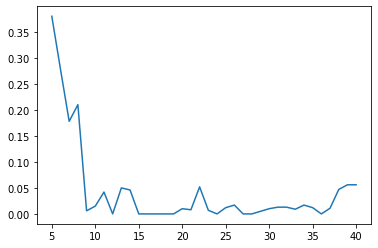

In [70]:
performance_monte_carlo(clean_sample('''
Va’, pensiero, sull'ali dorate;
va’, ti posa sui clivi, sui colli,
ove olezzano tepide e molli
l'aure dolci del suolo natal!

Del Giordano le rive saluta,
di Sionne le torri atterrate...
Oh, mia patria sì bella e perduta!
Oh, membranza sì cara e fatal!

Arpa d'or dei fatidici vati,
perché muta dal salice pendi?
Le memorie nel petto raccendi,
ci favella del tempo che fu!

O simile di Solima ai fati
traggi un suono di crudo lamento,
o t'ispiri il Signore un concento
che ne infonda al patire virtù!
'''), 'italian')

Watching the graph seems that classifier works better with l between 5 and 7 then the performance drastically decay this is probably due to the fact that a small string is less wrong interpretated than a longer string that has an higher probablity to be misinterpreted.

## Appendix A

In [54]:
import unicodedata
def sa(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')